# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Primero se importa pandas para poder abrir los archivos de datos. Se utiliza la función pd.read_csv() junto con el argumento sep=";", ya que al revisar el contenido general de los archivos se observa que los datos están separados por punto y coma. Para explorar cada tabla se usa el método .info(), y en el caso del archivo más grande se añade show_counts=True para visualizar de forma completa los recuentos de datos existentes y los posibles valores faltantes. Por último, se decide utilizar .head() para entender mejor el contenido.

In [1]:
import pandas as pd

In [2]:
instacart_orders= pd.read_csv("/datasets/instacart_orders.csv", sep= ";")
products= pd.read_csv("/datasets/products.csv", sep= ";")
aisles= pd.read_csv("/datasets/aisles.csv", sep= ";")
departments= pd.read_csv("/datasets/departments.csv", sep= ";")
order_products= pd.read_csv("/datasets/order_products.csv",sep= ";")

In [3]:
instacart_orders.info()
print(instacart_orders.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

In [4]:
products.info()
print(products.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  


In [5]:
aisles.info()
print(aisles.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [6]:
departments.info()
print(departments.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol


In [7]:
order_products.info(show_counts=True)
print(order_products.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1


## Conclusiones

Se cargaron correctamente los cinco archivos utilizando el separador adecuado. La exploración inicial permitió identificar la estructura de los datos y confirmar que algunos archivos son muy grandes, por lo que es necesario gestionar cuidadosamente su análisis.

# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

El plan de preprocesamiento incluye tres pasos principales: primero, identificar y eliminar registros duplicados para asegurar que cada dato sea único y evitar errores en el análisis; segundo, analizar los valores faltantes para entender su impacto y tratarlos adecuadamente, ya sea imputándolos o asignando valores representativos según su contexto; y tercero, ajustar los tipos de datos para que todas las columnas tengan el formato correcto, facilitando su procesamiento y análisis posterior. Este enfoque garantiza que los datos estén limpios, consistentes y preparados para un análisis confiable.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [8]:
# Revisa si hay pedidos duplicados
print(instacart_orders.duplicated().sum())
duplicated_orders = instacart_orders[instacart_orders.duplicated()]
print(duplicated_orders)

15
        order_id  user_id  order_number  order_dow  order_hour_of_day  \
145574    794638    50898            24          3                  2   
223105   2160484   107525            16          3                  2   
230807   1918001   188546            14          3                  2   
266232   1782114   106752             1          3                  2   
273805   1112182   202304            84          3                  2   
284038   2845099    31189            11          3                  2   
311713   1021560    53767             3          3                  2   
321100    408114    68324             4          3                  2   
323900   1919531   191501            32          3                  2   
345917   2232988    82565             1          3                  2   
371905    391768    57671            19          3                  2   
394347    467134    63189            21          3                  2   
411408   1286742   183220            48         

¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

En este caso se identificaron 15 filas duplicadas. Al analizar estos registros, se observa que coinciden en varios aspectos: todos corresponden a pedidos realizados el día miércoles y además comparten la misma hora de pedido, específicamente a las 2:00 a.m.

In [9]:
# Basándote en tus hallazgos,
# Verifica todos los pedidos que se hicieron el miércoles a las 2:00 a.m.

print(instacart_orders.query("order_dow == 3 and order_hour_of_day == 2"))

        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

¿Qué sugiere este resultado?

Los pedidos filtrados coinciden en día y hora (miércoles a las 2:00 a.m.), pero no son duplicados, ya que corresponden a distintos usuarios y pedidos, reflejando un patrón recurrente y no un error en los datos.

In [10]:
# Elimina los pedidos duplicados
instacart_orders= instacart_orders.drop_duplicates()

In [11]:
# Vuelve a verificar si hay filas duplicadas
print(instacart_orders.duplicated().sum())

0


In [12]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
print(instacart_orders.duplicated(subset= "order_id").sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Se confirmó que no existen IDs de pedido duplicados en el conjunto de datos, lo que garantiza que cada orden es única y no hay registros repetidos a nivel de identificador. Esto permite trabajar con confianza en el análisis sin preocuparse por duplicidades en los pedidos.

### `products` data frame

In [13]:
# Verifica si hay filas totalmente duplicadas
print(products.duplicated().sum())

0


In [14]:
# Revisa únicamente si hay ID de productos duplicados
print(products.duplicated(subset= "product_id").sum())

0


In [15]:
# Revisa únicamente si hay nombres duplicados de productos (convierte los nombres a letras mayúsculas para compararlos mejor)
products["product_name"]= products["product_name"].str.upper()
duplicate_names=products.duplicated(subset= "product_name").sum()
print(duplicate_names)


1361


In [16]:
# Revisa si hay nombres duplicados de productos no faltantes
valid_products = products[products["product_name"].notna()]
valid_products["product_name"] = valid_products["product_name"].str.upper()
duplicate_names=valid_products.duplicated(subset= "product_name").sum()
print(duplicate_names)

104


/tmp/ipykernel_32/3272357159.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_products["product_name"] = valid_products["product_name"].str.upper()


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Se encontró que algunos productos tienen el mismo nombre registrado más de una vez. Para revisarlo, primero se quitaron los productos sin nombre, luego se pasaron los nombres a mayúsculas para comparar mejor y finalmente se contó cuántos nombres están repetidos. Esto ayuda a detectar productos con nombres duplicados de forma más precisa.

### `departments` data frame

In [17]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())

0


In [18]:
# Revisa únicamente si hay IDs duplicadas de departamentos
print(departments.duplicated(subset= "department_id").sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Los resultados mostraron que no hay filas repetidas ni departamentos con el mismo ID en la tabla.Esto significa que cada departamento está registrado una sola vez, por lo que la información está ordenada y lista para usarse sin problemas ni confusiones por datos duplicados.

### `aisles` data frame

In [19]:
# Revisa si hay filas totalmente duplicadas
print(departments.duplicated().sum())

0


In [20]:
# Revisa únicamente si hay IDs duplicadas de pasillos
print(aisles.duplicated(subset= "aisle_id").sum())

0


Describe brevemente cuáles son tus hallazgos.

Los resultados mostraron que no hay filas repetidas ni IDs de pasillos duplicados. Esto significa que cada pasillo está registrado solo una vez, por lo que la información está limpia y lista para usarse sin riesgo de confusión por datos duplicados.

### `order_products` data frame

In [21]:
# Revisa si hay filas totalmente duplicadas
print(order_products.duplicated().sum())

0


In [22]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
print(order_products.duplicated(subset= ["order_id", 'product_id']).sum())

0


Describe brevemente cuáles son tus hallazgos.

No se encontraron filas duplicadas en el archivo, ni tampoco hay registros con el mismo producto repetido dentro de un mismo pedido. Esto indica que los datos están limpios y organizados, sin información repetida que pueda afectar el análisis.

## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [23]:
# Encuentra los valores ausentes en la columna 'product_name'
print(products["product_name"].isna().sum())

1258


Describe brevemente cuáles son tus hallazgos.

Hay 1,258 productos sin nombre en la columna product_name, lo que indica datos incompletos que pueden afectar análisis y reportes. 

In [24]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
missing_names= products[products["product_name"].isna()]
print(missing_names[missing_names["aisle_id"]==100])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

Todos los 1,258 productos sin nombre están asociados al pasillo con ID 100, lo que sugiere que el problema de datos incompletos está concentrado en ese pasillo específico. Esto indica una posible falla o inconsistencia en el registro o extracción de datos para ese pasillo.

In [25]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
missing_names= products[products["product_name"].isna()]
print(missing_names[missing_names["department_id"]==21])

       product_id product_name  aisle_id  department_id
37             38          NaN       100             21
71             72          NaN       100             21
109           110          NaN       100             21
296           297          NaN       100             21
416           417          NaN       100             21
...           ...          ...       ...            ...
49552       49553          NaN       100             21
49574       49575          NaN       100             21
49640       49641          NaN       100             21
49663       49664          NaN       100             21
49668       49669          NaN       100             21

[1258 rows x 4 columns]


Describe brevemente cuáles son tus hallazgos.

Los 1,258 productos que carecen de nombre están todos asociados al departamento con ID 21, indicando que la ausencia de datos se limita a ese departamento en particular.

In [26]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
aisle_100= aisles[aisles["aisle_id"]== 100]
print(aisle_100)
print()
department_21= departments[departments["department_id"]==21]
print(department_21)

    aisle_id    aisle
99       100  missing

    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

Los datos muestran que tanto el pasillo con ID 100 como el departamento con ID 21 están etiquetados como "missing". Esto indica que esos registros corresponden a productos sin clasificación específica, lo cual explica por qué los 1,258 productos asociados carecen de nombre.

In [27]:
# Completa los nombres de productos ausentes con 'Unknown'
products["product_name"].fillna("Unknown", inplace=True)
print(products["product_name"].isna().sum())

0


Describe brevemente cuáles son tus hallazgos.

Se completaron los 1,258 nombres de productos ausentes con la etiqueta "Unknown", resolviendo así el problema de valores nulos en la columna product_name. 

### `orders` data frame

In [28]:
# Encuentra los valores ausentes
print(instacart_orders.isna().sum())

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [29]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
missing_days= instacart_orders[instacart_orders["days_since_prior_order"].isna()]
print(missing_days["order_number"].unique())

[1]


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Los valores ausentes en days_since_prior_order corresponden únicamente al primer pedido de cada usuario, por lo que son datos faltantes esperados y no representan un problema en la información.

### `order_products` data frame

In [30]:
# Encuentra los valores ausentes
print(order_products.isna().sum())

order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [31]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
print(order_products["add_to_cart_order"].max())
print(order_products["add_to_cart_order"].min())

64.0
1.0


Describe brevemente cuáles son tus hallazgos.

Los valores mínimos y máximos en la columna add_to_cart_order son 1.0 y 64.0, respectivamente. Además, hay 836 valores ausentes, lo que indica que en esos casos no se registró el orden de agregado al carrito.

In [32]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
missing_add_to_cart_order= order_products[order_products["add_to_cart_order"].isna()]
order_ids_with_missing= missing_add_to_cart_order["order_id"].unique()
print(order_ids_with_missing)

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [33]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

product_counts= missing_add_to_cart_order.groupby("order_id")["product_id"].count()
if product_counts.min() > 64:
    print("Todos los pedidos tienen más de 64 productos")
else:
    print("Hay pedidos con 64 o menos productos")


Hay pedidos con 64 o menos productos


In [34]:
# Código del revisor
order_products[order_products['order_id'].isin(missing_add_to_cart_order['order_id'])].groupby('order_id')['product_id'].count().min()

65

Describe brevemente cuáles son tus hallazgos.

Los pedidos que tienen valores ausentes en la columna add_to_cart_order no siempre contienen más de 64 productos; algunos tienen 64 o menos. Esto indica que la ausencia de datos en esa columna no está limitada únicamente a pedidos muy grandes, sino que también ocurre en pedidos de tamaño más pequeño.

In [35]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
order_products["add_to_cart_order"]= order_products["add_to_cart_order"].fillna(999).astype(int)
print(order_products["add_to_cart_order"].isna().sum())

0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Reemplacé los valores ausentes en la columna add_to_cart_order por 999 y convertí toda la columna al tipo entero. Después de esta operación, verifiqué que ya no quedaran valores faltantes en esa columna, confirmando que el conteo de valores ausentes es cero. 

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

El proceso de preprocesamiento permitió identificar y corregir problemas comunes en los datos, como duplicados y valores faltantes, asegurando la calidad y confiabilidad de la información. La eliminación de registros duplicados garantiza que cada pedido y producto sea único, evitando inconsistencias en el análisis. El tratamiento de los valores ausentes se realizó de forma contextualizada, respetando los casos en los que estos valores son esperados y completando aquellos que podrían afectar los resultados. Finalmente, la transformación de los tipos de datos asegura un formato uniforme y adecuado para el análisis. Con estas acciones, se cuenta ahora con un conjunto de datos limpio y listo para su uso en tareas analíticas o de modelado.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:

# [A] Fácil (deben completarse todos para aprobar)

1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [36]:
if instacart_orders["order_hour_of_day"].min() >= 0 and instacart_orders["order_hour_of_day"].max()<= 23:
    print("Los valores son razonables para la columna order_hour_of_day")
else:
    print("Los valores no son razonables para la columna order_hour_of_day")

Los valores son razonables para la columna order_hour_of_day


In [37]:
if instacart_orders["order_dow"].min() >= 0 and instacart_orders["order_dow"].max()<= 6:
    print("Los valores son razonables para la columna order_dow")
else:
    print("Los valores no son razonables para la columna order_dow")

Los valores son razonables para la columna order_dow


Escribe aquí tus conclusiones

Los resultados confirman que los valores en las columnas order_hour_of_day y order_dow son consistentes y razonables, ya que se encuentran dentro de los rangos esperados. Esto indica que no existen errores de captura en estas variables y que los datos son aptos para análisis relacionados con horarios y días de la semana.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

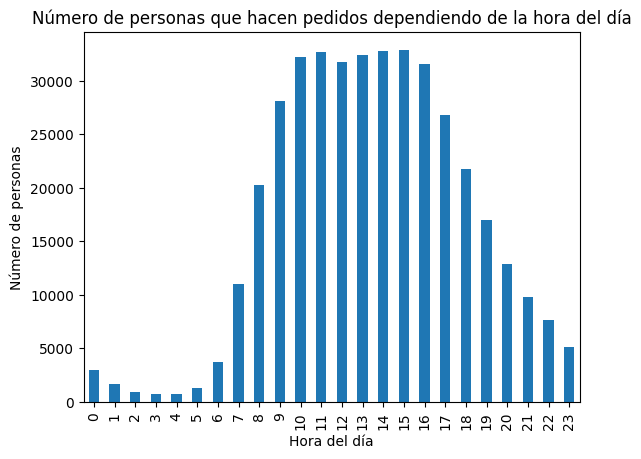

In [38]:
from matplotlib import pyplot as plt
orders_by_hour= instacart_orders.groupby("order_hour_of_day")["user_id"].nunique()
#Se agrupan los datos por la columna "order_hour_of_day", que indica la hora en que se hizo cada pedido.
#Dentro de cada grupo (cada hora), se cuentan los usuarios únicos (nunique()), es decir, cuántas personas hicieron pedidos en esa hora.
orders_by_hour.plot(title= "Número de personas que hacen pedidos dependiendo de la hora del día", kind= "bar", xlabel= "Hora del día", ylabel= "Número de personas")
#Como orders_by_hour es una serie, .plot() usa automáticamente el índice como eje x y los valores como eje y.
plt.show()

Escribe aquí tus conclusiones

Los datos muestran que la mayor cantidad de personas realiza pedidos entre las 10:00 y las 16:00 horas, mientras que la actividad disminuye considerablemente durante la madrugada, entre las 00:00 y las 06:00 horas.

### [A3] ¿Qué día de la semana compran víveres las personas?

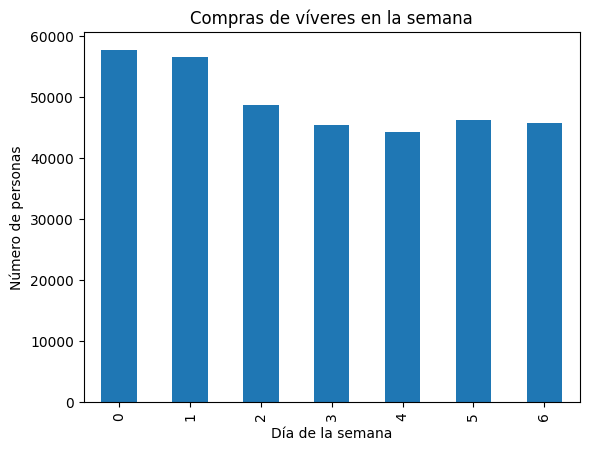

In [39]:
orders_by_hour= instacart_orders.groupby("order_dow")["user_id"].nunique()
orders_by_hour.plot(title= "Compras de víveres en la semana", kind= "bar", xlabel= "Día de la semana", ylabel= "Número de personas")
plt.show()

Escribe aquí tus conclusiones

Según la gráfica, el día con mayor número de compras de víveres fue el domingo, mientras que el jueves registró la menor cantidad de pedidos.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

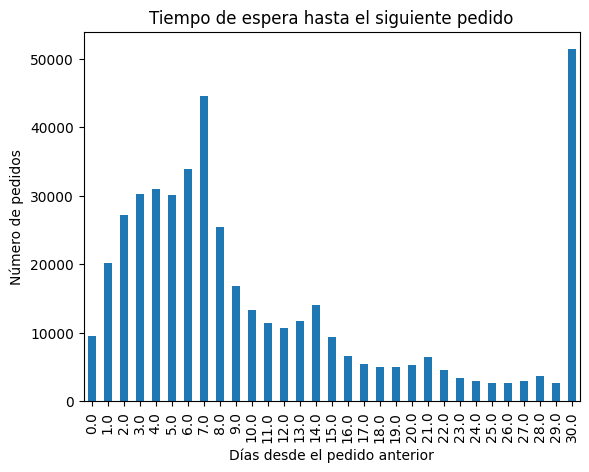

Día mínimo registrado: 0.0
Día máximo registrado: 30.0


In [40]:
days_wait= instacart_orders["days_since_prior_order"].value_counts().sort_index()
#Se cuentan cuántos pedidos hay para cada valor y se orden los resultados de menor a mayor 
days_wait.plot(title= "Tiempo de espera hasta el siguiente pedido", kind= "bar", xlabel= "Días desde el pedido anterior", ylabel= "Número de pedidos")
plt.show()
min_days= instacart_orders["days_since_prior_order"].min()
max_days= instacart_orders["days_since_prior_order"].max()
print(f"Día mínimo registrado: {min_days}")
print(f"Día máximo registrado: {max_days}")

Escribe aquí tus conclusiones

De acuerdo con la gráfica, la mayoría de los usuarios suele esperar 30 días o más para realizar su siguiente pedido, lo que indica un patrón de compra mensual. Además, se observa un segundo pico significativo en los 7 días, lo que sugiere un hábito semanal en otro grupo de clientes. Por otro lado, es poco común que las personas hagan un nuevo pedido el mismo día, es decir, con un tiempo de espera de 0 días.

# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

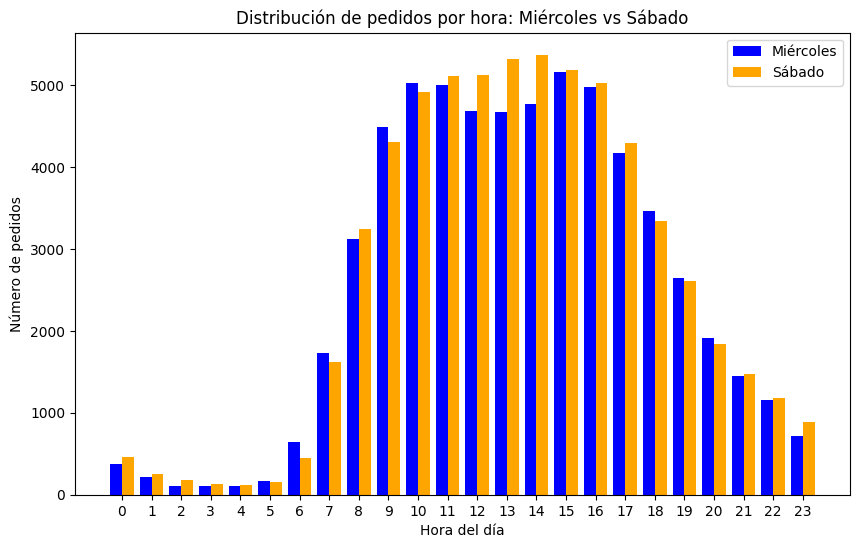

In [41]:
wednesday_orders = instacart_orders[instacart_orders["order_dow"] == 3]
saturday_orders = instacart_orders[instacart_orders["order_dow"] == 6]

wednesday_counts = wednesday_orders["order_hour_of_day"].value_counts().sort_index()
saturday_counts = saturday_orders["order_hour_of_day"].value_counts().sort_index()

plt.figure(figsize=(10,6))
plt.bar(wednesday_counts.index - 0.2, wednesday_counts.values, width=0.4, label="Miércoles", color="blue")
plt.bar(saturday_counts.index + 0.2, saturday_counts.values, width=0.4, label="Sábado", color="orange")

plt.xlabel("Hora del día")
plt.ylabel("Número de pedidos")
plt.title("Distribución de pedidos por hora: Miércoles vs Sábado")
plt.xticks(range(24))
plt.legend()
plt.show()

Escribe aquí tus conclusiones

La comparación de las distribuciones de pedidos por hora entre miércoles y sábados muestra diferencias claras en los patrones de compra. Aunque ambos días comparten ciertas horas pico, hay momentos específicos en los que uno supera al otro en cantidad de pedidos. Por ejemplo, los sábados tienden a concentrar más pedidos en horas de la tarde, mientras que los miércoles presentan un flujo de pedidos más repartido a lo largo del día. Esto sugiere que los hábitos de compra varían según el día de la semana, probablemente debido a diferencias en rutinas laborales y de tiempo libre.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

In [42]:
# Contar cuántos pedidos hizo cada usuario
user_orders = instacart_orders["user_id"].value_counts()
# Contar cuántos usuarios hicieron n pedidos
orders_per_user = user_orders.value_counts().sort_index()

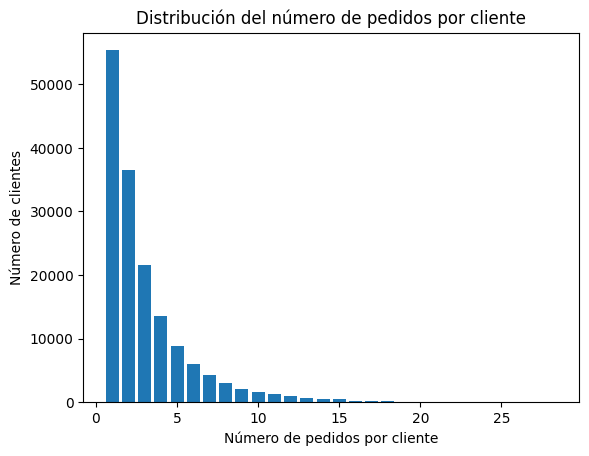

In [43]:
plt.bar(orders_per_user.index, orders_per_user.values)
plt.xlabel("Número de pedidos por cliente")
plt.ylabel("Número de clientes")
plt.title("Distribución del número de pedidos por cliente")
plt.show()

Escribe aquí tus conclusiones

De acuerdo con la gráfica, la mayoría de los clientes realiza pocos pedidos, siendo más común que hagan menos de 5. Aunque existen algunos usuarios que alcanzan los 10 pedidos o más, estos representan una minoría. Esto indica que la base de clientes está compuesta principalmente por compradores ocasionales, mientras que los clientes recurrentes son menos frecuentes.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [44]:
#Se cuenta cuántas veces aparece cada product_id
top_products = order_products["product_id"].value_counts().head(20).reset_index()
#Se cambian los nombres de las columnas para ser más claros 
top_products.columns = ["product_id", "order_count"]

In [45]:
top_products = top_products.merge(products[["product_id", "product_name"]], on="product_id", how="left")

In [46]:
print(top_products[["product_id", "product_name"]])

    product_id              product_name
0        24852                    BANANA
1        13176    BAG OF ORGANIC BANANAS
2        21137      ORGANIC STRAWBERRIES
3        21903      ORGANIC BABY SPINACH
4        47209      ORGANIC HASS AVOCADO
5        47766           ORGANIC AVOCADO
6        47626               LARGE LEMON
7        16797              STRAWBERRIES
8        26209                     LIMES
9        27845        ORGANIC WHOLE MILK
10       27966       ORGANIC RASPBERRIES
11       22935      ORGANIC YELLOW ONION
12       24964            ORGANIC GARLIC
13       45007          ORGANIC ZUCCHINI
14       39275       ORGANIC BLUEBERRIES
15       49683            CUCUMBER KIRBY
16       28204        ORGANIC FUJI APPLE
17        5876             ORGANIC LEMON
18        8277  APPLE HONEYCRISP ORGANIC
19       40706    ORGANIC GRAPE TOMATOES


Escribe aquí tus conclusiones

Los 20 productos más pedidos son principalmente frutas y verduras, muchas de ellas orgánicas, como plátanos, fresas, aguacates y leche orgánica. Esto muestra que a los clientes les gusta comprar alimentos frescos y saludables. La gran cantidad de productos orgánicos indica que hay una preferencia clara por opciones naturales. Estos datos pueden ayudar a enfocarse en tener siempre disponibles estos productos que son los favoritos de los compradores.

# [C] Difícil (deben completarse todos para aprobar)

1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [47]:
import pandas as pd
order_products = pd.read_csv("/datasets/order_products.csv", sep= ";")
from matplotlib import pyplot as plt
#Para contar cuentos productos hay por pedido
products_per_order = order_products.groupby("order_id")["product_id"].count()


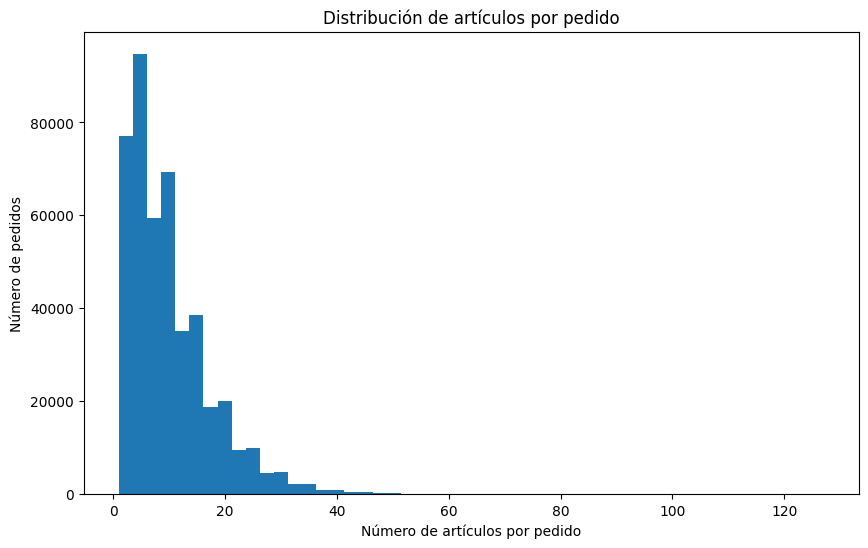

In [48]:
plt.figure(figsize=(10,6))
plt.hist(products_per_order, bins=50)
plt.xlabel("Número de artículos por pedido")
plt.ylabel("Número de pedidos")
plt.title("Distribución de artículos por pedido")
plt.show()

Escribe aquí tus conclusiones
Se puede decir que la distribución es asimétrica hacia la derecha (sesgada a la derecha), ya que la mayor parte de los pedidos tiene pocos artículos y solo una pequeña proporción de pedidos incluye una cantidad elevada de productos. Esto indica que la mayoría de los clientes hace compras pequeñas o moderadas.

### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [49]:
#Filtrar los productos que fueron reeordenados
reordered_products= order_products[order_products["reordered"]==1]

In [50]:
#Contar las veces que se repite cada producto
reorder_counts= reordered_products["product_id"].value_counts().head(20).reset_index()

In [51]:
#Se renombran las columnas
reorder_counts.columns = ['product_id', 'reorder_count']

In [52]:
#Se unen con nombres de productos
result = reorder_counts.merge(products[['product_id', 'product_name']], on='product_id')
print(result[['product_id', 'product_name', 'reorder_count']])

    product_id              product_name  reorder_count
0        24852                    BANANA          55763
1        13176    BAG OF ORGANIC BANANAS          44450
2        21137      ORGANIC STRAWBERRIES          28639
3        21903      ORGANIC BABY SPINACH          26233
4        47209      ORGANIC HASS AVOCADO          23629
5        47766           ORGANIC AVOCADO          18743
6        27845        ORGANIC WHOLE MILK          16251
7        47626               LARGE LEMON          15044
8        27966       ORGANIC RASPBERRIES          14748
9        16797              STRAWBERRIES          13945
10       26209                     LIMES          13327
11       22935      ORGANIC YELLOW ONION          11145
12       24964            ORGANIC GARLIC          10411
13       45007          ORGANIC ZUCCHINI          10076
14       49683            CUCUMBER KIRBY           9538
15       28204        ORGANIC FUJI APPLE           8989
16        8277  APPLE HONEYCRISP ORGANIC        

Escribe aquí tus conclusiones

El análisis muestra que los productos más reordenados son principalmente frutas, verduras y productos frescos, lo que refleja un patrón de compra recurrente en artículos de consumo habitual. Estos resultados son útiles para entender las preferencias de los clientes y planificar estrategias de inventario y marketing.

### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [53]:
# Se juntan todas las filas que tienen el mismo product_id.
# Se calcula el promedio de la columna reordered para cada grupo.
# El promedio da la proporción de reordenes.
proportion = order_products.groupby('product_id')['reordered'].mean().reset_index()

In [54]:
# Unir con nombres
#La unión se hace usando la columna en común: product_id.
result = proportion.merge(products[['product_id', 'product_name']], on='product_id')

In [55]:
print(result[['product_id', 'product_name', 'reordered']].head(20))

    product_id                                       product_name  reordered
0            1                         CHOCOLATE SANDWICH COOKIES   0.564286
1            2                                   ALL-SEASONS SALT   0.000000
2            3               ROBUST GOLDEN UNSWEETENED OOLONG TEA   0.738095
3            4  SMART ONES CLASSIC FAVORITES MINI RIGATONI WIT...   0.510204
4            7                     PURE COCONUT WATER WITH ORANGE   0.500000
5            8                  CUT RUSSET POTATOES STEAM N' MASH   0.315789
6            9                  LIGHT STRAWBERRY BLUEBERRY YOGURT   0.761905
7           10     SPARKLING ORANGE JUICE & PRICKLY PEAR BEVERAGE   0.448071
8           11                                  PEACH MANGO JUICE   0.625000
9           12                         CHOCOLATE FUDGE LAYER CAKE   0.390244
10          13                                  SALINE NASAL MIST   0.500000
11          14                     FRESH SCENT DISHWASHER CLEANER   0.000000

Escribe aquí tus conclusiones

El análisis muestra que algunos productos son reordenados con mayor frecuencia que otros, destacando alimentos y bebidas con proporciones de recompra superiores al 70%, como el té o los yogurts, mientras que otros productos tienen proporciones cercanas a cero, lo que indica que son compras ocasionales o de prueba. Esto refleja diferencias en los hábitos de consumo y la recurrencia de ciertos artículos.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [56]:
# Se unen las tablas para saber qué cliente hizo cada pedido
merged = order_products.merge(instacart_orders[['order_id', 'user_id']], on='order_id')

# Se calcula proporción de reordenes por cliente
proportion = merged.groupby('user_id')['reordered'].mean().reset_index()

# Se renombra la columna para que sea más claro
proportion.columns = ['user_id', 'reorder_proportion']


In [57]:
print(proportion.head(20))

    user_id  reorder_proportion
0         2            0.038462
1         4            0.000000
2         5            0.666667
3         6            0.000000
4         7            0.928571
5        11            0.200000
6        12            0.250000
7        13            0.565217
8        14            0.360656
9        15            0.538462
10       16            0.531250
11       17            0.716981
12       19            0.291667
13       20            0.000000
14       21            0.400000
15       22            1.000000
16       24            0.500000
17       26            0.437500
18       27            0.658824
19       28            0.500000


Escribe aquí tus conclusiones

La proporción de productos reordenados varía entre clientes, mostrando que algunos tienden a repetir la mayoría de sus compras, mientras que otros prefieren probar productos nuevos con más frecuencia. Esto refleja distintos hábitos de compra y lealtad dentro de la base de clientes.

### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [58]:
# Filtrar productos que fueron añadidos primero al carrito (add_to_cart_order == 1)
first_in_cart = order_products[order_products['add_to_cart_order'] == 1]

In [59]:
# Contar cuántas veces cada producto fue el primero
top_first = first_in_cart['product_id'].value_counts().head(20).reset_index()
top_first.columns = ['product_id', 'first_count']

In [60]:
# Unir con nombres de productos
result = top_first.merge(products[['product_id', 'product_name']], on='product_id')
print(result[['product_id', 'product_name', 'first_count']])

    product_id                 product_name  first_count
0        24852                       BANANA        15562
1        13176       BAG OF ORGANIC BANANAS        11026
2        27845           ORGANIC WHOLE MILK         4363
3        21137         ORGANIC STRAWBERRIES         3946
4        47209         ORGANIC HASS AVOCADO         3390
5        21903         ORGANIC BABY SPINACH         3336
6        47766              ORGANIC AVOCADO         3044
7        19660                 SPRING WATER         2336
8        16797                 STRAWBERRIES         2308
9        27966          ORGANIC RASPBERRIES         2024
10       44632   SPARKLING WATER GRAPEFRUIT         1914
11       49235          ORGANIC HALF & HALF         1797
12       47626                  LARGE LEMON         1737
13         196                         SODA         1733
14       38689     ORGANIC REDUCED FAT MILK         1397
15       26209                        LIMES         1370
16       12341                H

Escribe aquí tus conclusiones

Los resultados muestran que los productos que más frecuentemente se añaden primero al carrito son principalmente frutas frescas, especialmente plátanos y sus versiones orgánicas, así como productos lácteos orgánicos y bebidas como agua y refrescos. Esto indica que los consumidores suelen comenzar su compra con productos básicos y frescos que probablemente son parte esencial de su lista de compras habitual.

### Conclusion general del proyecto:

Escribe aquí tus conclusiones

Al analizar los datos de Instacart, pudimos entender mejor cómo compran los clientes. Vimos cuáles son los productos que más se piden y cuáles vuelven a comprar con frecuencia. También descubrimos qué productos suelen agregar primero al carrito. Notamos que cada cliente tiene diferentes hábitos: algunos repiten mucho sus compras y otros prueban cosas nuevas. Esta información puede ayudar a mejorar la forma en que Instacart organiza sus productos y ofrece recomendaciones a sus usuarios.